# **Exploratory Data Analysis of Historical Stock Market Data**

## **Introduction**:

This project focuses on the Exploratory Data Analysis (EDA) of historical stock market data from 1970 to 2018. We will use two datasets. The historical_stocks.csv dataset contains information about stocks, including ticker, exchange, company name, sector, and industry. The historical_stock_prices.csv dataset contains historical stock data, including ticker, open, close, adjusted close, low, high, volume, and date. The two datasets are linked through the ticker column.
Using Python, we will explore and understand the datasets before conducting more advanced analyses. Specifically, we will inspect the data, assess data quality, explore stock information, identify unusual observations, create visualizations, analyze stock prices over time, and identify opportunities for further analysis.

## **Part 1 — Load and Understand the Data**

### **Import libraries**

In [1]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Load the datasets**

In [ ]:
# Load the datasets

stock_data = pd.read_csv("historical_stocks.csv")
stock_price_data = pd.read_csv("historical_stock_prices.csv")

### **Inspect to understand the historical_stock dataset**

In [ ]:
# Display the first five rows for the stock data

stock_data.head()

,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS


In [14]:
# Inspect the datasets structure and dimension

stock_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   ticker    6460 non-null   str  
 1   exchange  6460 non-null   str  
 2   name      6460 non-null   str  
 3   sector    5020 non-null   str  
 4   industry  5020 non-null   str  
dtypes: str(5)
memory usage: 640.9 KB


In [15]:
stock_data.shape

(6460, 5)

### **Inspect to understand the historical_stock_Price dataset**

In [6]:
# Display the first five rows for the stock price data

stock_price_data.head()

,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14


In [11]:
# Find the company info for AHH

stock_data[stock_data["ticker"] == "AHH"]

,ticker,exchange,name,sector,industry
3543,AHH,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE


In [ ]:
# Inspect the datasets structure and dimension

stock_price_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   ticker     str    
 1   open       float64
 2   close      float64
 3   adj_close  float64
 4   low        float64
 5   high       float64
 6   volume     int64  
 7   date       str    
dtypes: float64(5), int64(1), str(2)
memory usage: 1.5 GB


In [9]:
stock_price_data.shape

(20973889, 8)

### **Key insights from the dataset inspection:**

To be able to analyse our data, we loaded our datasets in the following way: Data from the "historical_stocks.csv" were stored in a variable called "stock_data" while data from "historical_stock_prices.csv" were stored in a variable called "stock_price_data". 

The historical_stocks dataset contains information about historical stock/securities. It includes the stock ticker (Identifier), the exchange where the stock is listed, the company name, and its sector and industry classifications. The ticker variable available also in the historical stock price will be used to link this dataset with the historical stock price dataset. The dataset has 6,460 records (rows) and 5 variables (Columns). All variables are stored as strings (Categorical). The ticker, exchange, and name columns have no missing values, while sector and industry each contain missing values. 

The historical_stock_prices dataset contains historical stock data. It has 20,973,889 records and 8 variables. It includes five continuous numerical variables (open, close, adj_close, low, and high), one integer variable (volume), and two string variables (ticker and date). The date variable is currently stored as a string and will be converted to a datetime format in the future steps for time-series analysis.

## **Part 2 — Check Data Quality**

### **Identify missing values**

In [ ]:
# Check for the number of missing values per column

print(stock_data.isnull().sum())

ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64


In [23]:
# Percentage of missing values

print((stock_data.isnull().sum() / len(stock_data)) * 100)

ticker       0.000000
exchange     0.000000
name         0.000000
sector      22.291022
industry    22.291022
dtype: float64


In [ ]:
# Check for the number of missing values per column

print(stock_price_data.isnull().sum())

ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64


In [ ]:
# Check/Understand the sector column

stock_data["sector"].value_counts(dropna=False)

sector
NaN                      1440
FINANCE                  1022
CONSUMER SERVICES         796
HEALTH CARE               784
TECHNOLOGY                607
CAPITAL GOODS             352
ENERGY                    286
PUBLIC UTILITIES          273
BASIC INDUSTRIES          272
CONSUMER NON-DURABLES     224
CONSUMER DURABLES         144
MISCELLANEOUS             139
TRANSPORTATION            120
SECTOR                      1
Name: count, dtype: int64

In [26]:
# Confirm whether the sector column has missing values

stock_data[stock_data["sector"].isnull()].head()

,ticker,exchange,name,sector,industry
19,ABP,NASDAQ,ABPRO CORPORATION,NaN,NaN
42,SQZZ,NASDAQ,ACTIVE ALTS CONTRARIAN ETF,NaN,NaN
62,ACT,NASDAQ,ADVISORSHARES VICE ETF,NaN,NaN
100,ABDC,NASDAQ,ALCENTRA CAPITAL CORP.,NaN,NaN
124,SMCP,NASDAQ,ALPHAMARK ACTIVELY MANAGED SMALL CAP ETF,NaN,NaN


In [ ]:
# Identify the erroneous repeated header (SECTOR)

stock_data[stock_data["sector"] == "SECTOR"]

,ticker,exchange,name,sector,industry
74,Symbol,NYSE,NAME,SECTOR,INDUSTRY


In [28]:
# Are sector and industry missing together?

stock_data[["sector", "industry"]].isnull().sum()

sector      1440
industry    1440
dtype: int64

In [30]:
stock_data[stock_data["sector"].isnull() != stock_data["industry"].isnull()]

,ticker,exchange,name,sector,industry


In [25]:
# Check and understand the exchange column
stock_data["exchange"].value_counts(dropna=False)


exchange
NASDAQ    3308
NYSE      3152
Name: count, dtype: int64

#### **Insights on missing values:**
We identified 1,440 missing values in both the sector and industry columns, representing 22.3% of the records. Since the other information for these stocks, such as ticker and company name, is available, these records should not be considered removed. Instead, because they are categorical variables, they will be replaced by "Uknown".

We identified one invalid record was identified at index 74, containing header-like values such as “Symbol,” “NAME,” “SECTOR,” and “INDUSTRY.” Since this record does not represent an actual stock, it was classified as a data-quality error and will be removed from the dataset in the next steps.


### **Check for duplicates**

In [21]:
# Check for dplicates

print(stock_data.duplicated().sum())


0


In [31]:
print(stock_price_data.duplicated(subset=["ticker", "date"]).sum())

0


#### **Insights on duplicates**

To check for duplicates in the stock price dataset, we created a combined index of ticker and date, since each ticker should have only one record for a given date. The analysis found no duplicate records. Similarly, the stock dataset was checked for duplicate tickers, and no duplicates were identified.

### **Check the number of unique stocks**

In [42]:
stock_data["ticker"].nunique()

6460

In [43]:
stock_price_data["ticker"].nunique()

5685

### **Check if ticker appears only one time in the stock dataset**

In [44]:
stock_data["ticker"].is_unique

True

### **Compute the tickers in the stock dataset that have price data**

In [45]:
stock_data["ticker"].isin(stock_price_data["ticker"]).value_counts()

ticker
True     5685
False     775
Name: count, dtype: int64

### **Identify stocks that do not have any price records in stock_price_data**

In [48]:
stock_data.loc[~stock_data["ticker"].isin(stock_price_data["ticker"])].head(15)

,ticker,exchange,name,sector,industry
9,CAFD,NASDAQ,8POINT3 ENERGY PARTNERS LP,PUBLIC UTILITIES,ELECTRIC UTILITIES: CENTRAL
15,ABEOW,NASDAQ,ABEONA THERAPEUTICS INC.,HEALTH CARE,MAJOR PHARMACEUTICALS
18,ABLX,NASDAQ,ABLYNX NV,HEALTH CARE,BIOTECHNOLOGY: BIOLOGICAL PRODUCTS (NO DIAGNOS...
19,ABP,NASDAQ,ABPRO CORPORATION,NaN,NaN
60,ADXSW,NASDAQ,"ADVAXIS, INC.",HEALTH CARE,MAJOR PHARMACEUTICALS
74,Symbol,NYSE,NAME,SECTOR,INDUSTRY
83,AGFSW,NASDAQ,"AGROFRESH SOLUTIONS, INC.",FINANCE,BUSINESS SERVICES
112,AHGP,NASDAQ,"ALLIANCE HOLDINGS GP, L.P.",ENERGY,COAL MINING
129,AMRWW,NASDAQ,"ALTA MESA RESOURCES, INC.",FINANCE,BUSINESS SERVICES
140,AMBCW,NASDAQ,"AMBAC FINANCIAL GROUP, INC.",FINANCE,PROPERTY-CASUALTY INSURERS


#### **Insights**
The stock_data dataset contains 6,460 unique stock tickers, and each ticker appears only once, confirming that there are no duplicate tickers. In comparison, the stock_price_data dataset contains price records for 5,685 unique tickers.
By comparing the ticker values between the two datasets, 5,685 stocks were found to have historical price data, while 775 stocks had no corresponding price records. Further inspection of the stocks without price data also identified a header artifact at index 74, where values such as Symbol, NAME, SECTOR, and INDUSTRY appeared as a data record. Since this row does not represent an actual stock, we will remove it as part of the data-cleaning process.
The remaining stocks without price records are not necessarily data errors. They may represent stocks for which historical price information is unavailable in the price dataset. Therefore, they can remain in the stock information dataset but should be excluded from analyses that require historical price data.

## **Part 3 — Prepare and Explore the Date**

### **Convert date format**

In [ ]:
# Convert the data type for date column

stock_price_data["date"] = pd.to_datetime(stock_price_data["date"])

In [ ]:
# Check the data type

stock_price_data.dtypes

ticker                  str
open                float64
close               float64
adj_close           float64
low                 float64
high                float64
volume                int64
date         datetime64[us]
dtype: object

### **Check the date range**

In [ ]:
# Earliest date

stock_price_data["date"].min()

Timestamp('1970-01-02 00:00:00')

In [39]:
# Latest date

stock_price_data["date"].max()

Timestamp('2018-08-24 00:00:00')

#### **Insights on date format:**
Date which was in string format was converted into datetime to allow the timeseries analysis. This will help us to analyze stock price trends over time, daily or monthly changes, stock volume trends, moving averages, and stock performance over specific periods. The earliest date in the dataset is January 2, 1970 while the latest date is August 24, 2018.

## **Part 4 — Explore Categorical Data**

#### **Number of securities in each exchange**

In [ ]:
# Compute the number of securities are associated with each exchange.

stock_data.groupby("exchange")["ticker"].count()

exchange
NASDAQ    3308
NYSE      3152
Name: ticker, dtype: int64

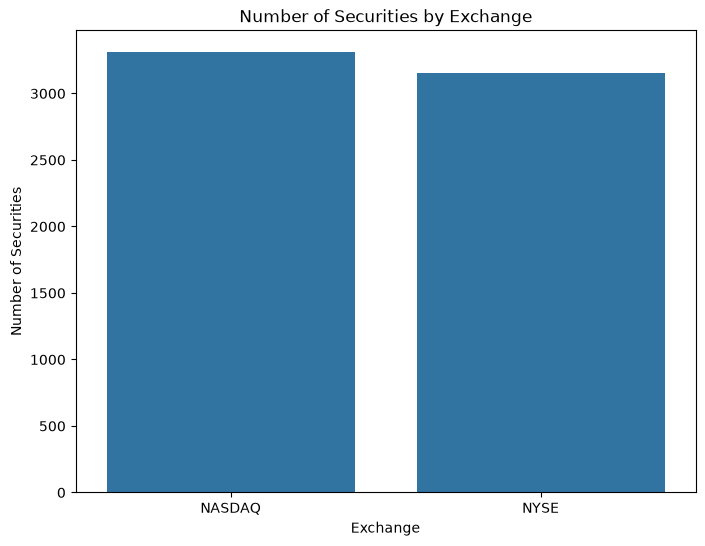

In [53]:
# Which exchange has more securities in this dataset?

plt.figure(figsize=(8, 6))

sns.countplot(data=stock_data, x="exchange")

plt.title("Number of Securities by Exchange")
plt.xlabel("Exchange")
plt.ylabel("Number of Securities")

plt.show()

#### **Insights:**

NASDAQ has more securities than NYSE in the dataset. NASDAQ contains approximately 3,300 securities, compared with about 3,150 securities on NYSE.

#### **Number of securities in each sector**

In [57]:
# Compute the number of securities by sector

stock_data.groupby("sector")["ticker"].count().sort_values(ascending=False)

sector
FINANCE                  1022
CONSUMER SERVICES         796
HEALTH CARE               784
TECHNOLOGY                607
CAPITAL GOODS             352
ENERGY                    286
PUBLIC UTILITIES          273
BASIC INDUSTRIES          272
CONSUMER NON-DURABLES     224
CONSUMER DURABLES         144
MISCELLANEOUS             139
TRANSPORTATION            120
SECTOR                      1
Name: ticker, dtype: int64

In [61]:
# Securities with missing sectors

print("Securities with missing sectors:", stock_data["sector"].isnull().sum())

Securities with missing sectors: 1440


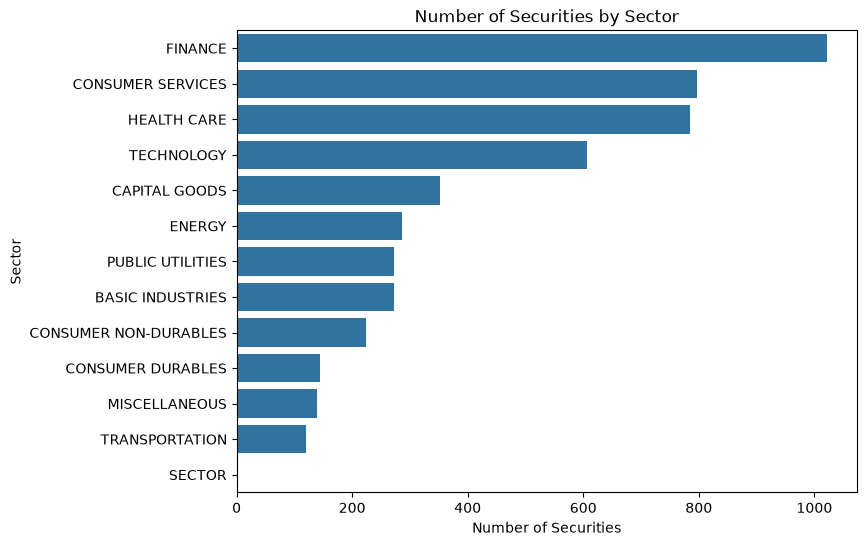

In [65]:
# Visualize the securities by sector

plt.figure(figsize=(8,6))

sns.countplot(data=stock_data, y=stock_data["sector"], order=stock_data["sector"].value_counts().index)
plt.title("Number of Securities by Sector")
plt.xlabel("Number of Securities")
plt.ylabel("Sector")
plt.show()

#### **Insigths**:

Which sectors contain the most securities: The Finance sector has the highest number of securities (1,022), followed by Consumer Services (796), Health Care (784), and Technology (607).

Possible reasons for missing sector information: About 1440 securities do not have sectors. Some of the reasons may be because Some securities may not have been classified into a specific sector, and the sector data were unavailable when the dataset was created.

SECTOR = 1 seems to be an erroneous header row included in the data and should not be considered a sector.

## **Part 5 — Explore Numerical Data**

In [67]:
# Summary statistics for the stock price numerical variables

stock_price_data.drop(columns=["ticker", "date"]).describe()

,open,close,adj_close,low,high,volume
count,2.097389e+07,2.097389e+07,2.097389e+07,2.097389e+07,2.097389e+07,2.097389e+07
mean,7.605823e+01,7.611403e+01,1.481184e+14,7.422064e+01,7.803857e+01,1.227043e+06
std,2.849639e+03,2.870159e+03,4.574674e+16,2.746059e+03,2.997937e+03,1.316686e+07
min,4.000000e-04,2.000000e-04,2.282650e-09,1.000000e-04,4.000000e-04,1.000000e+00
25%,7.500000e+00,7.500000e+00,4.620000e+00,7.360000e+00,7.630000e+00,2.210000e+04
50%,1.545000e+01,1.545000e+01,1.138199e+01,1.524000e+01,1.566000e+01,1.260000e+05
75%,2.972000e+01,2.972000e+01,2.472046e+01,2.928000e+01,3.010000e+01,6.074000e+05
max,2.034000e+06,1.779750e+06,1.894962e+19,1.440000e+06,2.070000e+06,4.483504e+09


In [68]:
pd.set_option("display.float_format", "{:,.2f}".format)

In [69]:
stock_price_data.drop(columns=["ticker", "date"]).describe()

,open,close,adj_close,low,high,volume
count,"20,973,889.00","20,973,889.00","20,973,889.00","20,973,889.00","20,973,889.00","20,973,889.00"
mean,76.06,76.11,"148,118,439,358,488.62",74.22,78.04,"1,227,043.03"
std,"2,849.64","2,870.16","45,746,744,518,955,968.00","2,746.06","2,997.94","13,166,864.47"
min,0.00,0.00,0.00,0.00,0.00,1.00
25%,7.50,7.50,4.62,7.36,7.63,"22,100.00"
50%,15.45,15.45,11.38,15.24,15.66,"126,000.00"
75%,29.72,29.72,24.72,29.28,30.10,"607,400.00"
max,"2,034,000.00","1,779,750.00","18,949,618,910,812,401,664.00","1,440,000.00","2,070,000.00","4,483,504,400.00"


## **Part 6 — Investigate Unusual Values**

#### **Investigate closing price**

In [92]:
# Investigate the highest closing prices

highest_close = stock_price_data.loc[
    stock_price_data["close"].nlargest(15).index,
    ["ticker", "date", "close", "adj_close", "volume"]]

highest_close

,ticker,date,close,adj_close,volume
12146443,SCON,2000-02-28,"1,779,750.00","1,779,750.00",400
12146459,SCON,2000-02-29,"1,595,250.00","1,595,250.00",400
12146546,SCON,2000-03-13,"1,363,500.00","1,363,500.00",300
17889354,CODA,2001-02-05,"1,354,500.00","1,354,500.00",34
2444619,TVIX,2013-02-26,"1,347,500.00","1,347,500.00",100
12146480,SCON,2000-03-02,"1,261,125.00","1,261,125.00",200
12146437,SCON,2000-02-25,"1,215,000.00","1,215,000.00",200
17107201,TOPS,2016-08-01,"1,189,800.00","1,189,800.00",100
12146465,SCON,2000-03-01,"1,134,000.00","1,134,000.00",300
12146562,SCON,2000-03-14,"1,111,500.00","1,111,500.00",100


#### **Insights**

Securities with the highest closing prices: The highest values were mainly associated with SCON, followed by CODA, TVIX, and TOPS. SCON had the highest closing price at $1,779,750.
When did they occur? The observations occurred between 2000 and 2016. The highest closing price occurred on February 28, 2000 for SCON.
Trading volume: Trading volumes were very low, ranging from 34 to 400 shares among these observations.
Do they appear unusual? Yes. These prices are extremely high compared with the overall median closing price of $15.45, and they occurred with very low trading volumes.
Can we conclude they are errors? No. Extreme values are not necessarily errors. Notably, close and adj_close are identical for these observations. The values could reflect historical pricing or corporate actions such as reverse stock splits. Therefore, they will be investigated rather than automatically removed.

#### **Investigate adj_close**

In [ ]:
# Investigate adj_close

stock_price_data.loc[stock_price_data["adj_close"].nlargest(15).index, ["ticker", "date", "close", "adj_close"]]

,ticker,date,close,adj_close
6174033,AAN,1987-02-27,1.30,"18,949,618,910,812,401,664.00"
6174039,AAN,1987-03-10,1.30,"18,949,618,910,812,401,664.00"
6174040,AAN,1987-03-11,1.30,"18,949,618,910,812,401,664.00"
6174041,AAN,1987-03-12,1.30,"18,949,618,910,812,401,664.00"
6174044,AAN,1987-03-17,1.30,"18,949,618,910,812,401,664.00"
6174045,AAN,1987-03-18,1.30,"18,949,618,910,812,401,664.00"
6174046,AAN,1987-03-19,1.30,"18,949,618,910,812,401,664.00"
6174049,AAN,1987-03-25,1.30,"18,949,618,910,812,401,664.00"
6174051,AAN,1987-03-27,1.29,"18,814,275,626,503,000,064.00"
6174050,AAN,1987-03-26,1.27,"18,543,558,271,558,500,352.00"


In [75]:
# Investigate AAN stock prices

aan_data = stock_price_data[stock_price_data["ticker"] == "AAN"]

aan_data[["date", "open", "close", "adj_close", "low", "high"]].sort_values("date")

,date,open,close,adj_close,low,high
6174006,1987-01-20,1.06,1.06,"15,430,410,944,278,200,320.00",1.06,1.06
6174007,1987-01-21,1.06,1.06,"15,430,410,944,278,200,320.00",1.06,1.06
6174008,1987-01-22,1.06,1.06,"15,430,410,944,278,200,320.00",1.06,1.09
6174009,1987-01-23,1.06,1.06,"15,430,410,944,278,200,320.00",1.06,1.09
6174010,1987-01-26,1.06,1.06,"15,430,410,944,278,200,320.00",1.06,1.06
...,...,...,...,...,...,...
6258947,2018-08-20,49.31,49.47,49.47,48.86,49.58
6258968,2018-08-21,49.53,50.17,50.17,49.50,50.49
6258991,2018-08-22,50.50,50.79,50.79,50.29,51.19
6259011,2018-08-23,50.89,50.85,50.85,50.69,51.53


In [93]:
# Identify very large adjusted closing prices
extreme_adj_close = stock_price_data[
    stock_price_data["adj_close"] > 1_000_000]

# Total number of observations
print("Total observations:", len(extreme_adj_close))

# Number of observations by ticker
print("\nObservations by ticker:")
print(extreme_adj_close["ticker"].value_counts())

Total observations: 1935

Observations by ticker:
ticker
ELJ     1100
AAN      824
SCON       7
TVIX       2
TOPS       1
CODA       1
Name: count, dtype: int64


In [76]:
# Identify AAN records with extremely large adjusted close values

aan_extreme = aan_data[aan_data["adj_close"] > 1_000_000]

print("Number of extreme records:", len(aan_extreme))
print("First extreme date:", aan_extreme["date"].min())
print("Last extreme date:", aan_extreme["date"].max())

Number of extreme records: 824
First extreme date: 1987-01-20 00:00:00
Last extreme date: 1994-01-20 00:00:00


In [86]:
# Investigate unusual adjusted closing prices

# Calculate the ratio between adjusted close and close
stock_price_data["adj_close_ratio"] = (
    stock_price_data["adj_close"] / stock_price_data["close"])


In [88]:
# Identify suspicious observations
suspicious = stock_price_data["adj_close_ratio"] > 100

print("Suspicious records:", suspicious.sum())
print("Affected tickers:", stock_price_data.loc[suspicious, "ticker"].unique())


Suspicious records: 2649
Affected tickers: <ArrowStringArray>
['AAN', 'ELJ']
Length: 2, dtype: str


In [89]:
# Display suspicious observations
stock_price_data.loc[
    suspicious,
    ["ticker", "date", "close", "adj_close", "adj_close_ratio"]
]

,ticker,date,close,adj_close,adj_close_ratio
6174006,AAN,1987-01-20,1.06,"15,430,410,944,278,200,320.00","14,618,283,685,603,497,984.00"
6174007,AAN,1987-01-21,1.06,"15,430,410,944,278,200,320.00","14,618,283,685,603,497,984.00"
6174008,AAN,1987-01-22,1.06,"15,430,410,944,278,200,320.00","14,618,283,685,603,497,984.00"
6174009,AAN,1987-01-23,1.06,"15,430,410,944,278,200,320.00","14,618,283,685,603,497,984.00"
6174010,AAN,1987-01-26,1.06,"15,430,410,944,278,200,320.00","14,618,283,685,603,497,984.00"
...,...,...,...,...,...
17125077,ELJ,2013-08-29,0.12,19.87,158.97
17125115,ELJ,2013-09-05,0.12,19.87,158.97
17125187,ELJ,2013-09-17,0.11,17.49,158.97
17125206,ELJ,2013-09-19,0.12,19.87,158.97


In [91]:
# check of the ratio distribution for these two tickers

stock_price_data.loc[
    stock_price_data["ticker"].isin(["AAN", "ELJ"]),
    ["ticker", "adj_close_ratio"]
].groupby("ticker").describe()

adj_close_ratio                             \
                 count                       mean   
ticker                                              
AAN           5,214.00 656,078,896,971,938,432.00   
ELJ           1,952.00                   1,411.74   

                                                                     \
                                std  min      25%      50%      75%   
ticker                                                                
AAN    3,026,835,848,466,039,296.00 0.86     0.96     0.98     1.00   
ELJ                          598.25 1.00 1,672.78 1,672.78 1,672.78   

                                      
                                 max  
ticker                                
AAN    14,618,288,326,889,478,144.00  
ELJ                         1,672.78

#### **Insigths on adj_close**

The extreme adj_close values are concentrated in ticker AAN, while the actual close prices are only around $1.26–$1.30. We then checked all AAN records to determine whether the problem affects only certain dates or the entire AAN history. We found that the extreme adj_close values for AAN occur in older historical records, while the recent records look normal. For example, in 1987, a closing price of $1.06 corresponds to an adjusted close of about $15.4 quintillion, whereas by 2018, close and adj_close are approximately equal. We then proceeded to determine when the abnormal adjusted prices stop. We realized that AAN has 824 extremely large adj_close values, occurring from January 20, 1987 to January 20, 1994. We finally ckecked whether other tickers also have extreme adj_close values and realized that the problem is not limited to AAN. There are 1,935 observations with adj_close > 1,000,000, spread across six tickers, with most coming from ELJ (1,100) and AAN (824). We then investigated unusual adj_close price by calculating the ratio between adjusted close and close. A ratio greater than 100 was used as a screening threshold to identify observations where the adjusted closing price was disproportionately large relative to the closing price. The adj_close/close ratio was used to investigate extreme adjusted closing prices. AAN showed unusually large ratios compared with its typical ratio of approximately 1, indicating anomalous values. ELJ also had high ratios, but these were common throughout its historical data and will therefore retained. Only the anomalous AAN adj_close values will be replaced with missing values (NaN).

## **Part 7 — Visualize the Data**

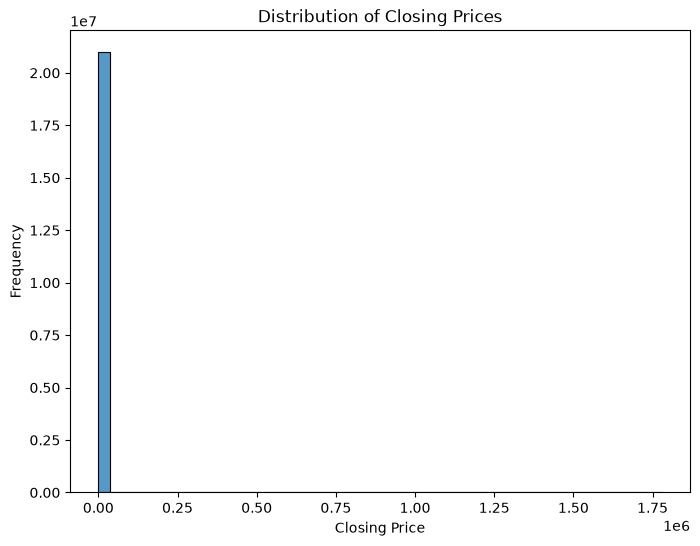

In [96]:
# Create a histogram of close

plt.figure(figsize=(8,6))

sns.histplot(stock_price_data["close"], bins=50)
plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.show()

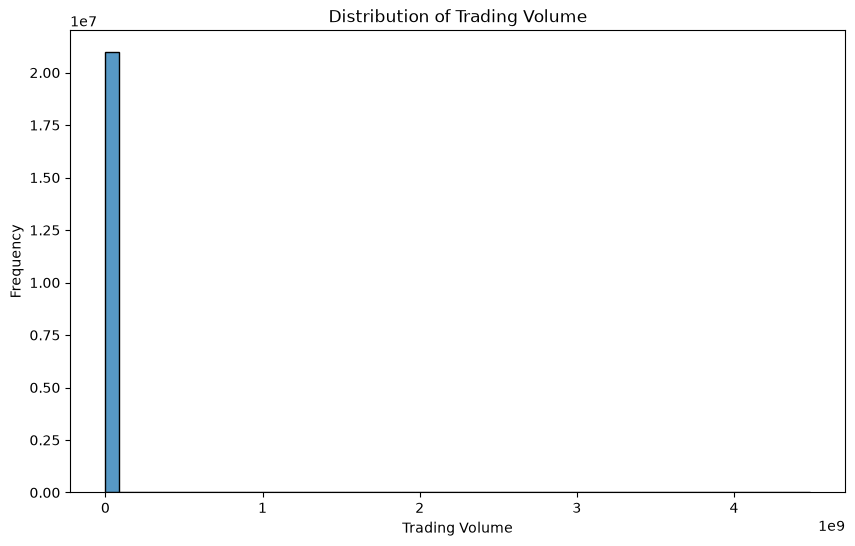

In [99]:
# Volume histogram

plt.figure(figsize=(10, 6))

sns.histplot(stock_price_data["volume"], bins=50)

plt.title("Distribution of Trading Volume")
plt.xlabel("Trading Volume")
plt.ylabel("Frequency")
plt.show()

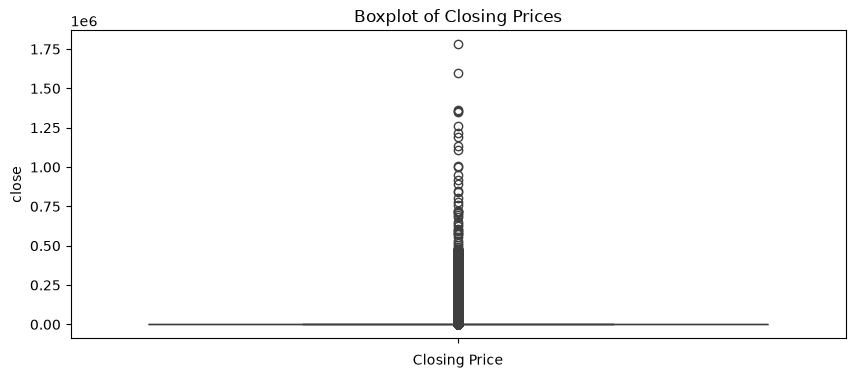

In [100]:
# Closing price boxplot

plt.figure(figsize=(10, 4))

sns.boxplot(stock_price_data["close"])
plt.title("Boxplot of Closing Prices")
plt.xlabel("Closing Price")
plt.show()

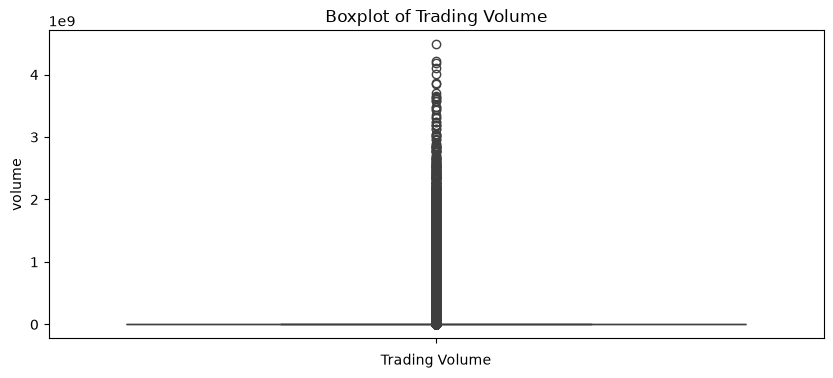

In [102]:
# Volume boxplot

plt.figure(figsize=(10, 4))

sns.boxplot(stock_price_data["volume"])
plt.title("Boxplot of Trading Volume")
plt.xlabel("Trading Volume")
plt.show()

#### **Insights**

The histograms show that both closing prices and trading volume are strongly right-skewed. This means that most of the approximately 21 million observations have relatively low values, while only a small number have extremely high values. Closing prices reach approximately $1.78 million, and trading volume reaches about 4.48 billion. The boxplots also show many potential outliers, especially at the higher end of the data. These findings agree with the descriptive statistics: the mean closing price ($76.11) is much higher than the median ($15.45), showing that a small number of very high prices increase the average. However, these potential outliers should be investigated before being removed, because unusual values are not necessarily errors.

In [104]:
# Filter MSFT data as selected ticker

msft_data = stock_price_data[
    stock_price_data["ticker"] == "MSFT"].sort_values("date")

## **Part 8 — Explore One Stock and Summarize Your Findings**